In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [2]:
%config InlineBackend.figure_format = 'retina'

import random
import time
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from nsppk import NSPPK

from abstractgraph_graphicalizer.chem import draw_molecules as display_graphs

from abstractgraph.operators import *
from abstractgraph.hashing import hash_graph
from abstractgraph.graphs import graph_to_abstract_graph
from abstractgraph.vectorize import AbstractGraphTransformer
from abstractgraph_ml.estimators import GraphEstimator
from abstractgraph_generative.conditional import ConditionalAutoregressiveGenerator
from abstractgraph_generative.conditional_attributed import AttributedConditionalAutoregressiveGenerator
from abstractgraph_generative.conditional_batch import  ConditionalAutoregressiveGraphsGenerator
from abstractgraph_generative.edge_generator import (
    EdgeGenerator,
    edge_neighbors,
    make_edge_regression_dataset,
    remove_edges,
)
from abstractgraph_generative.dataset_selection import select_graphs_via_shortest_paths


/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.2.0)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


In [3]:
from abstractgraph_ml.feasibility import (
    FeasibilityEstimator,
    FeasibilityEstimatorFeatureCannotExist,
)

nbits = 19
feasibility_kwargs = dict(
    nbits=nbits,
    parallel=True,
    backend='loky',
    n_jobs=-1,
)

feasibility_estimators = [
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(neighborhood(radius=2), unlabel()),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=path(number_of_edges=2),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=neighborhood(radius=1),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=cycle(),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(combination(number_of_elements=(2, 3), distance=0), cycle(), unlabel()),
        **feasibility_kwargs,
    ),
]

feasibility_estimator = FeasibilityEstimator(feasibility_estimators)

dataset: zinc_250k
size: 2000
node_range: [10, 13]
dataset size: 2000


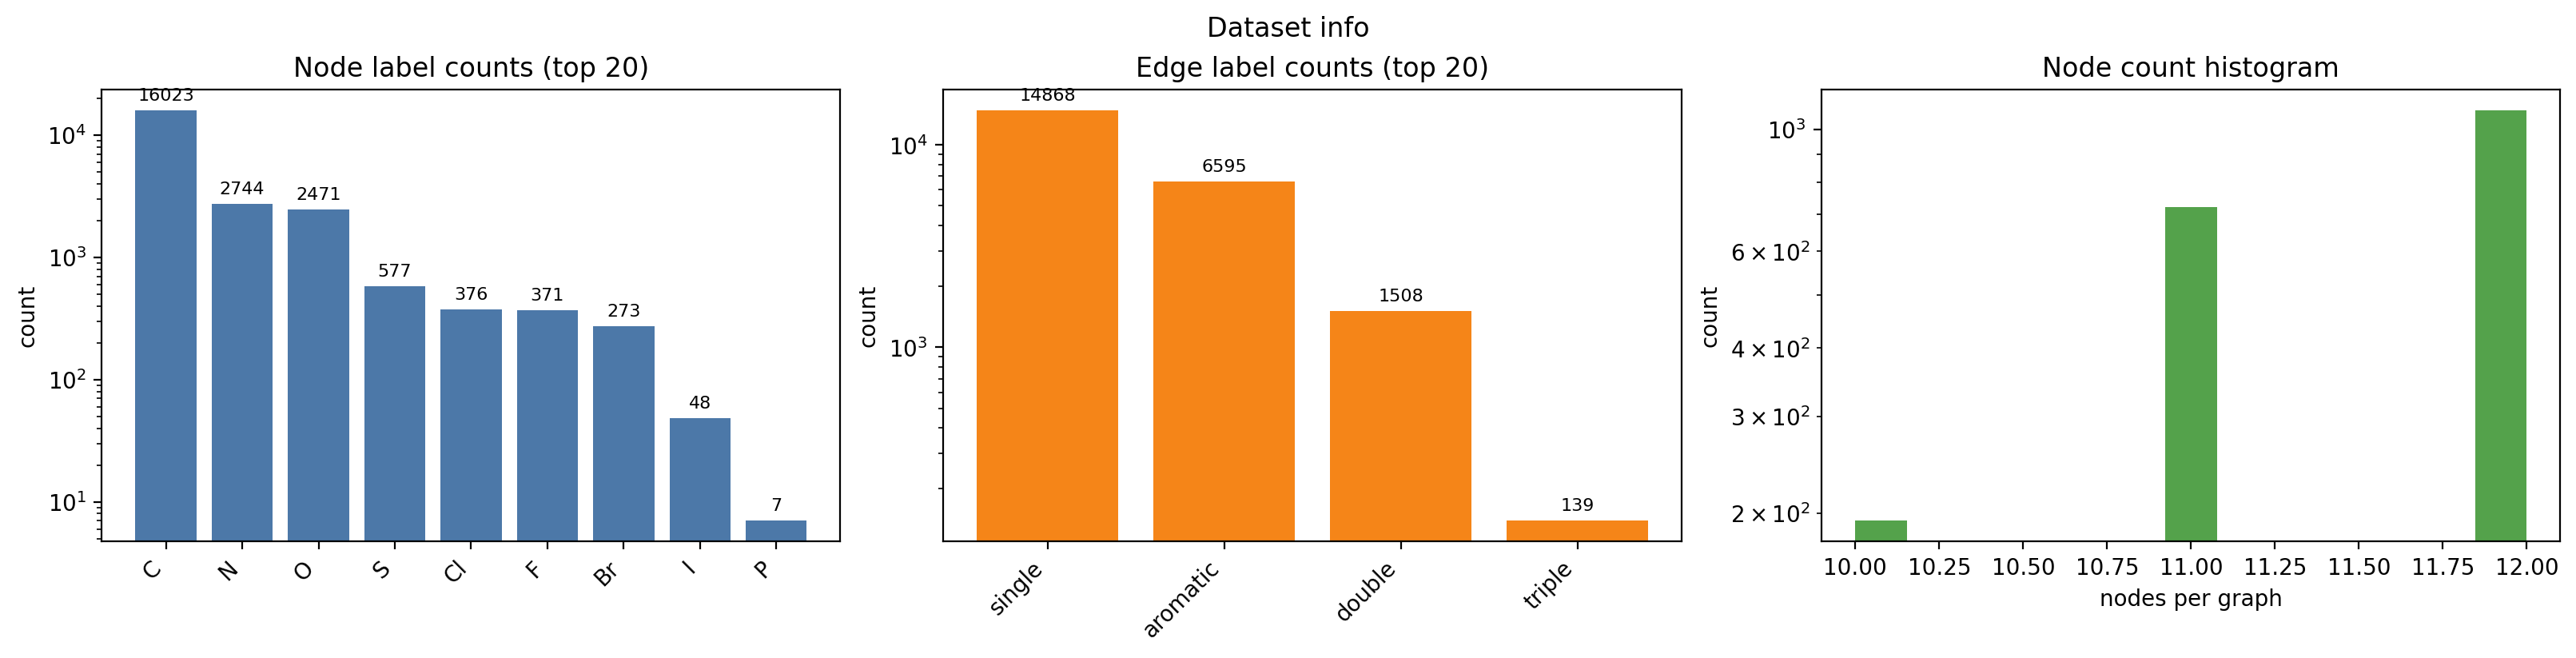

In [4]:
from abstractgraph_graphicalizer.chem import ZINCLoader

loader = ZINCLoader(on_error="skip")

dataset_name = "zinc_250k"
size = 2000
min_num_nodes = 10
max_num_nodes = 13

graphs, metadata = loader.load(
    dataset_name,
    limit=size,
    min_node_count=min_num_nodes,
    max_node_count=max_num_nodes,
)
print(f"dataset: {dataset_name}")
print(f"size: {len(graphs)}")
print(f"node_range: [{min_num_nodes}, {max_num_nodes}]")

from abstractgraph.utils import plot_graph_label_counts
_ = plot_graph_label_counts(graphs, top=20, title='Dataset info', log_scale=True)

# Keep downstream notebook cells unchanged
all_graphs = graphs
all_targets = metadata
print('dataset size:', len(all_graphs))


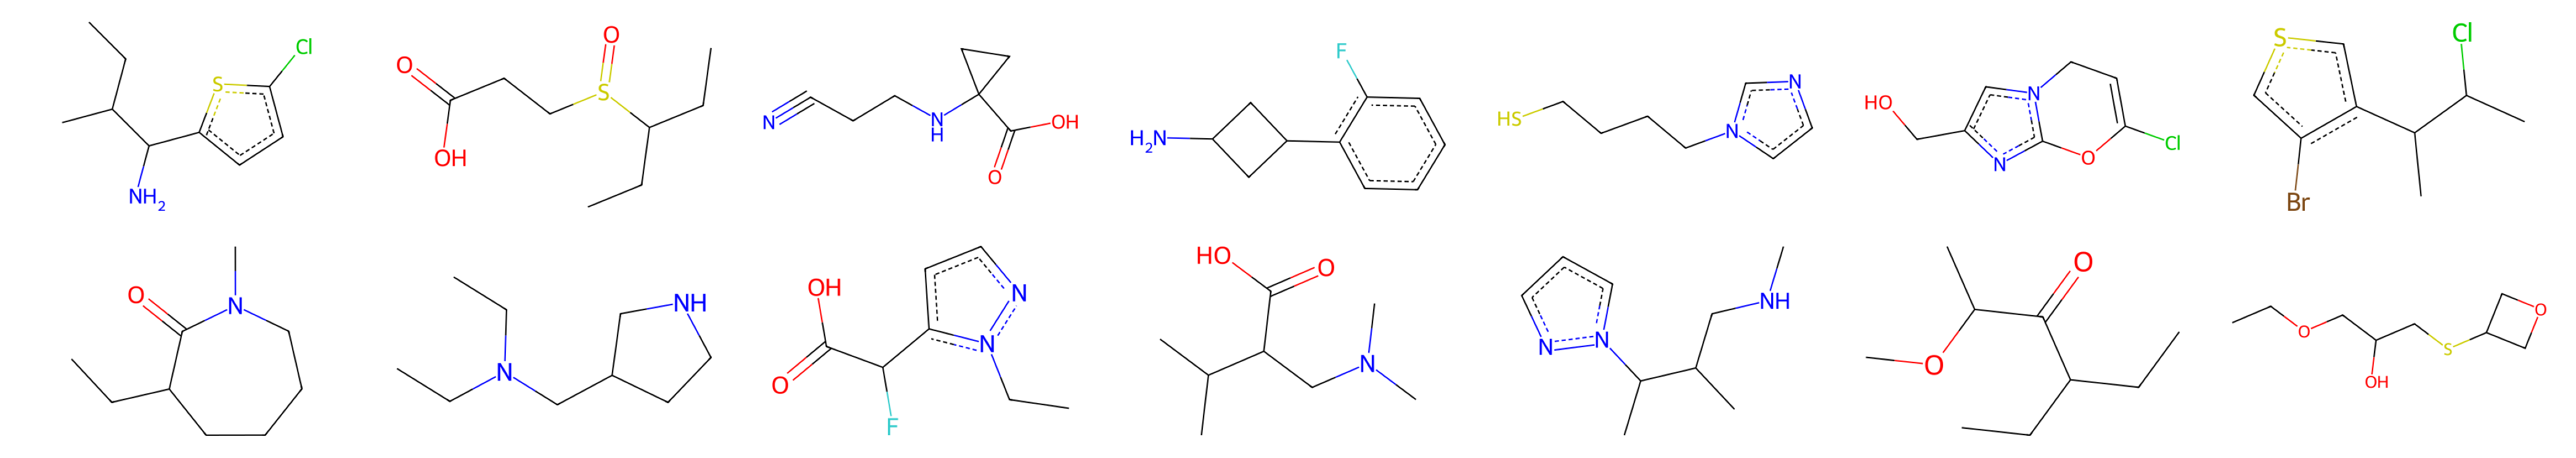

In [5]:
_ = display_graphs(graphs[:7*2], n_graphs_per_line=7)

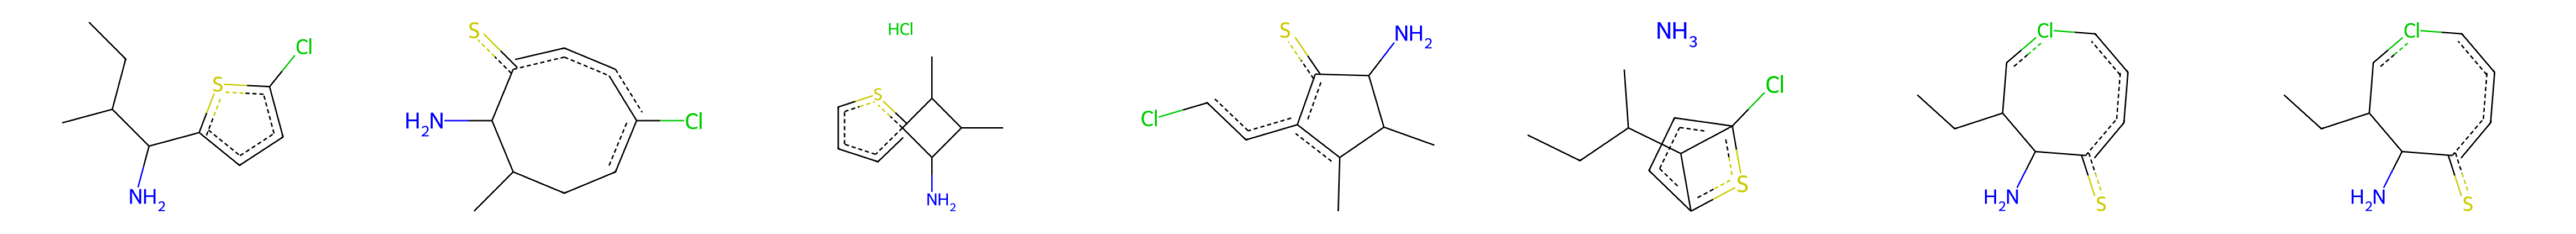

In [6]:
graph= graphs[0]
perturbed_graphs = edge_neighbors(graph, n_samples=6)
_ = display_graphs([graph]+perturbed_graphs, n_graphs_per_line=7)

In [7]:

n_negative_per_positive = 3
positives, negatives, dataset = make_edge_regression_dataset(
    graph,
    n_negative_per_positive=n_negative_per_positive,
    seed=0,
)

print('n_positives =', len(positives))
print('n_negatives =', len(negatives))
print('dataset_size =', len(dataset))
print('n_terminal_positives =', sum(G.number_of_edges() == 0 for G in positives))

n_positives = 12
n_negatives = 33
dataset_size = 45
n_terminal_positives = 1


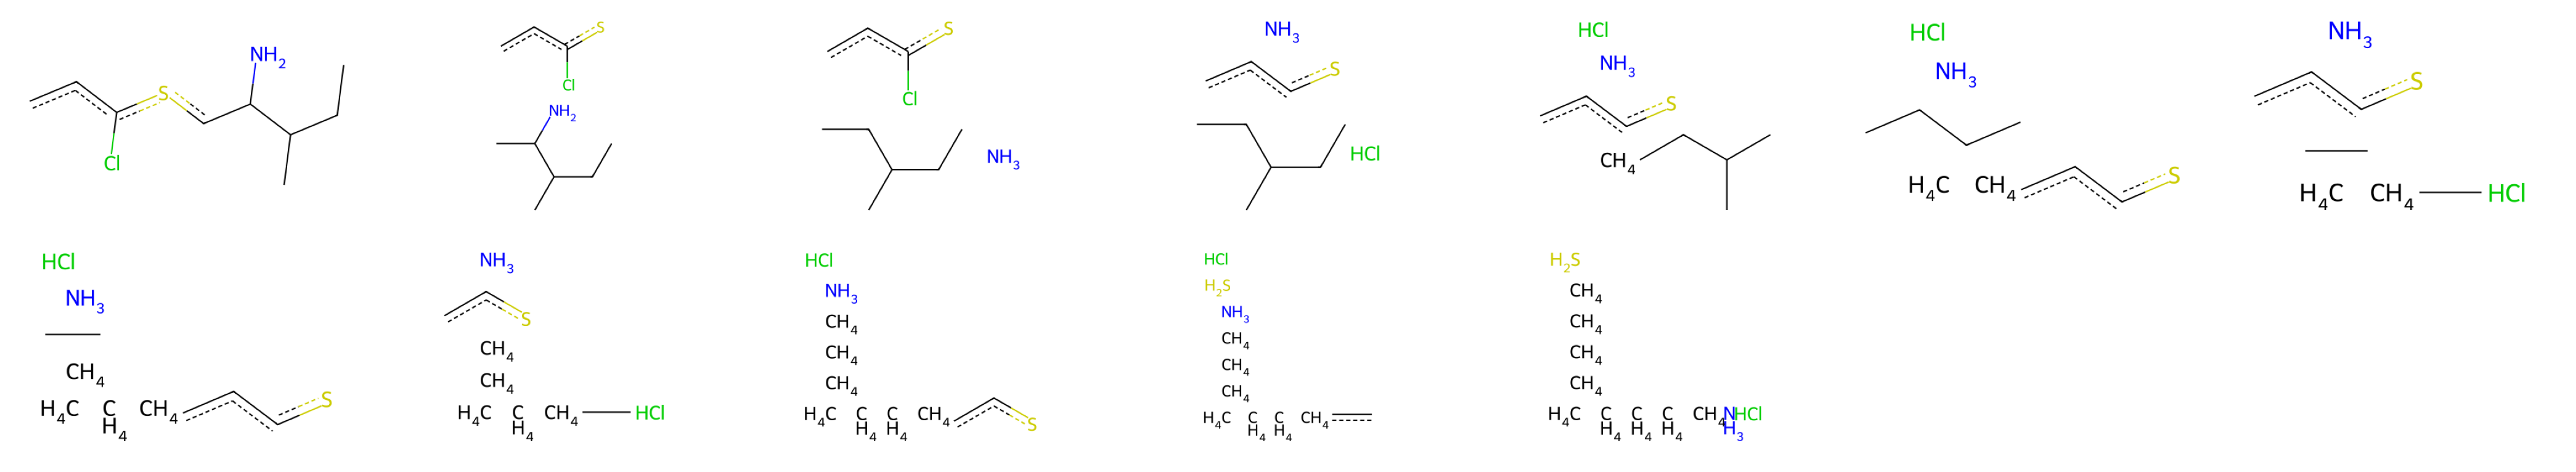

In [8]:
_ = display_graphs(positives[:7*2], n_graphs_per_line=7)

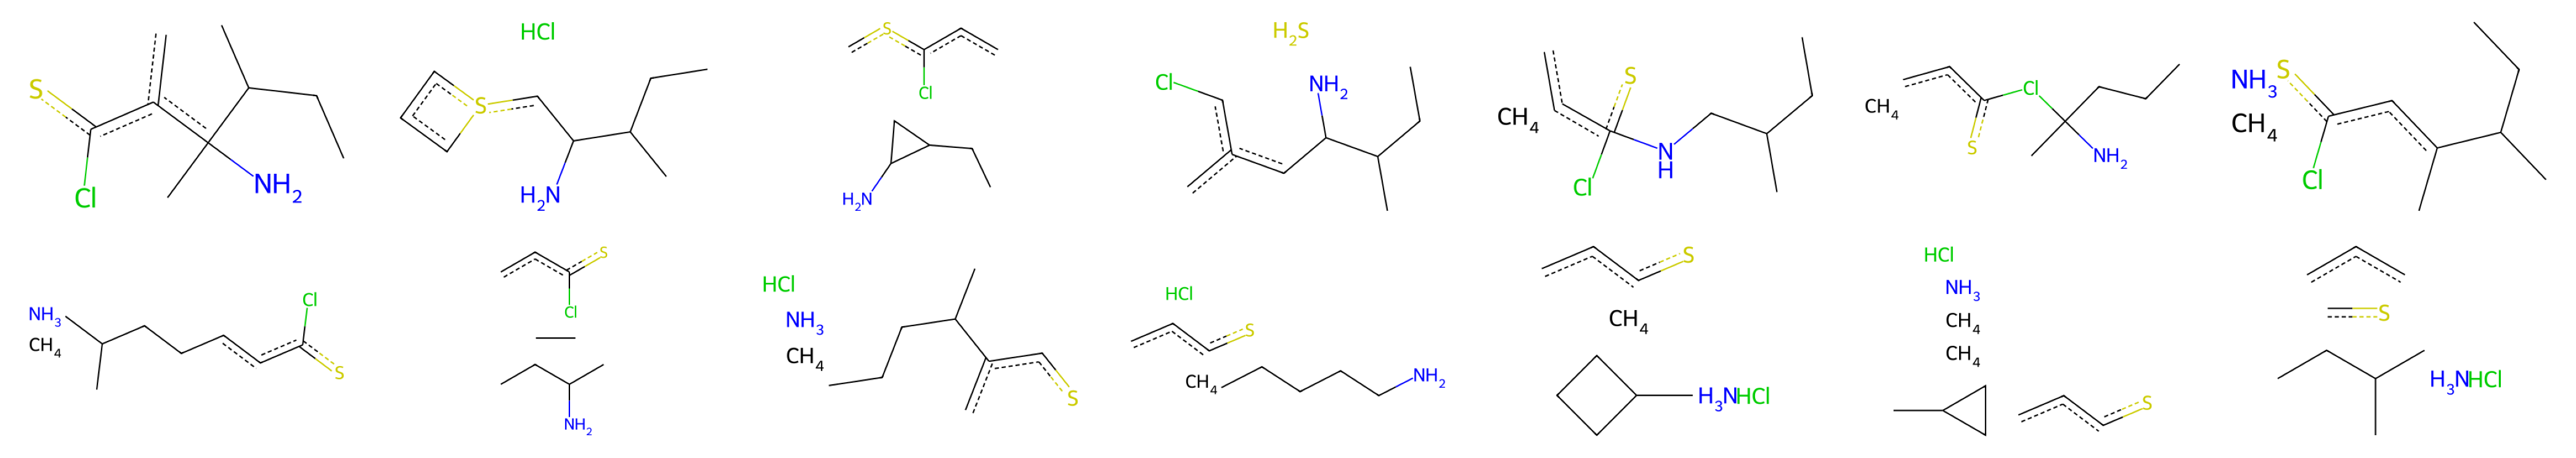

In [9]:
_ = display_graphs(negatives[:7*2], n_graphs_per_line=7)

Working on #graphs = 2000 to extract 3 paths
source_idx = 1729, dest_idx = 788


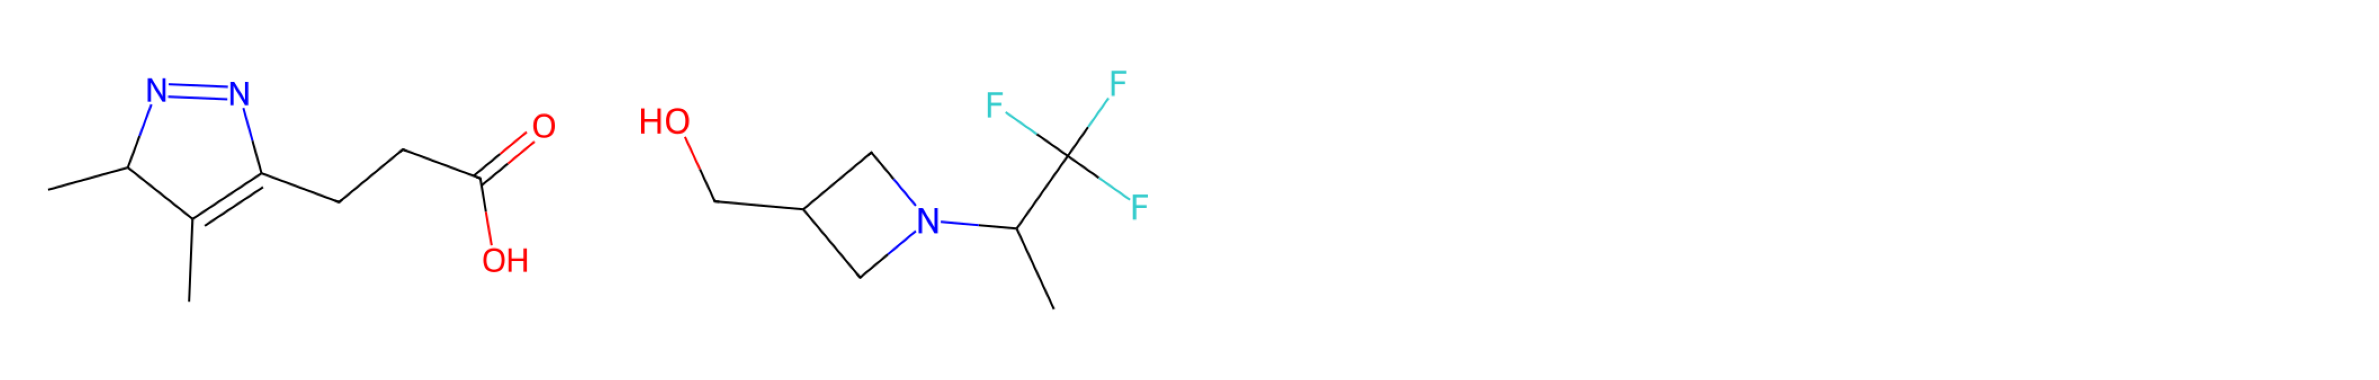

paths found = 3
fitting on 4 graphs
selected indices: [197, 788, 1729, 1983]
target values disabled


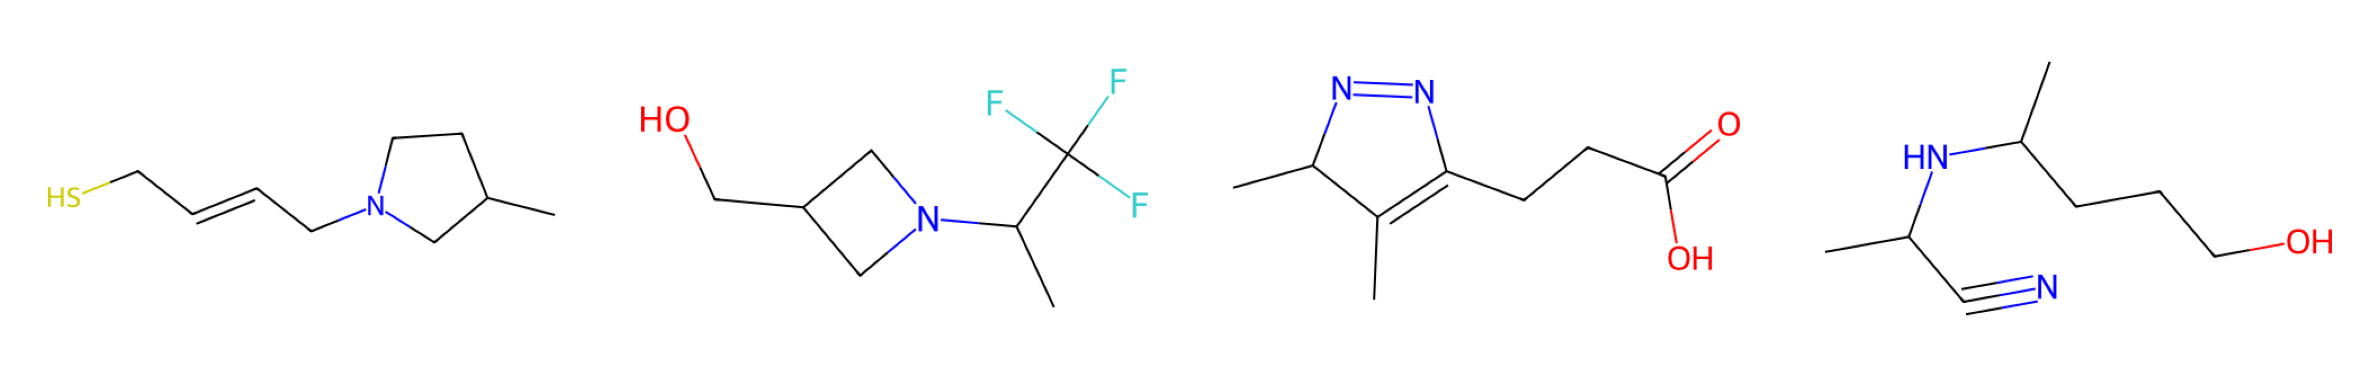

CPU times: user 36 s, sys: 2.54 s, total: 38.5 s
Wall time: 49.6 s


In [10]:
%%time
N_PATHS = 3
SOURCE_IDX = None
DEST_IDX = None
USE_TARGETS = False
selection_vectorizer = NSPPK(radius=1, distance=4, connector=0, nbits=14, parallel=True)
print(f'Working on #graphs = {len(graphs)} to extract {N_PATHS} paths')
selection = select_graphs_via_shortest_paths(
    graphs,
    vectorizer=selection_vectorizer,
    source_idx=SOURCE_IDX,
    dest_idx=DEST_IDX,
    n_paths=N_PATHS,
    random_state=0,
)
fit_indices = selection['selected_indices']
fit_paths = selection['paths']
fit_graphs = [graphs[idx] for idx in fit_indices]
fit_targets = [max(dict(graph.degree()).values(), default=0) for graph in fit_graphs] if USE_TARGETS else None

print(f"source_idx = {selection['source_idx']}, dest_idx = {selection['dest_idx']}")
_ = display_graphs([graphs[selection['source_idx']], graphs[selection['dest_idx']]], n_graphs_per_line=min(len(fit_graphs), 7))
print(f'paths found = {len(fit_paths)}')
print(f'fitting on {len(fit_graphs)} graphs')
print('selected indices:', fit_indices)
if USE_TARGETS:
    print('target values (max_degree):', sorted(set(fit_targets)))
else:
    print('target values disabled')
_ = display_graphs(fit_graphs, n_graphs_per_line=min(len(fit_graphs), 7))

In [11]:
%%time
USE_NSPPK = True

if USE_NSPPK:
    vectorizer = NSPPK(radius=1, distance=4, connector=1, nbits=14, parallel=True)
else:
    vectorizer = AbstractGraphTransformer(
        nbits=14,
        decomposition_function=neighborhood(radius=(1,2)),
        return_dense=True,
        n_jobs=-1,
    )
    
graph_estimator = GraphEstimator(
    transformer=vectorizer,
    estimator=RandomForestClassifier(
        random_state=0, 
        n_estimators=300, 
        n_jobs=-1, 
        class_weight="balanced_subsample",
        ),
)

target_estimator = None
if USE_TARGETS:
    target_estimator = GraphEstimator(
        transformer=vectorizer,
        estimator=RandomForestRegressor(
            random_state=0,
            n_estimators=300,
            n_jobs=-1,
        ),
    )

generative_bias_df = add(cycle(), tree())

generator = EdgeGenerator(
    feasibility_estimator,
    graph_estimator,
    target_estimator=target_estimator,
    target_estimator_mode='regression',
    decomposition_function=generative_bias_df,
    enforce_diversity=False,
    n_negative_per_positive=3,
    n_replicates=3,
    beam_size=2,
    fit_n_jobs=-1,
    fit_backend='loky',
    verbose=True,
    seed=0,
).fit(fit_graphs)

if USE_TARGETS:
    generator.fit_target_estimator(fit_graphs, fit_targets)


[fit] feasibility_graphs=118 positives=135 negatives=369 dataset=504 time=0m 10.8s
[fit] graph_estimator_graphs=504 positive_labels=135 negative_labels=369 time=0m 9.8s
CPU times: user 47.9 s, sys: 3.3 s, total: 51.2 s
Wall time: 49.6 s


Selecting random graph...


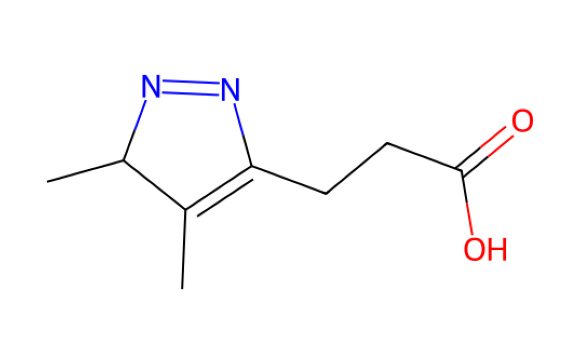

Removed edges to create start graph with target_n_edges = 12


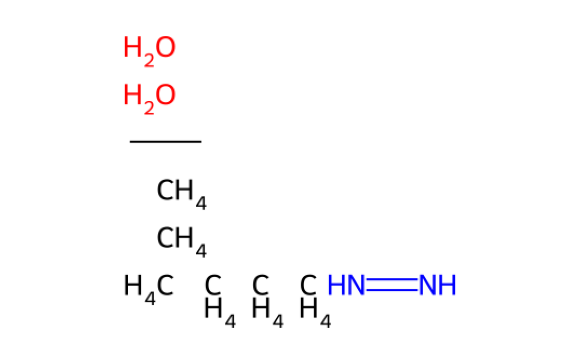

Generating path to target_n_edges = 12 and desired_target = None
[graph 0] start start_edges=2 target_edges=12 remaining_edges=10 target=None target_lambda=0.500


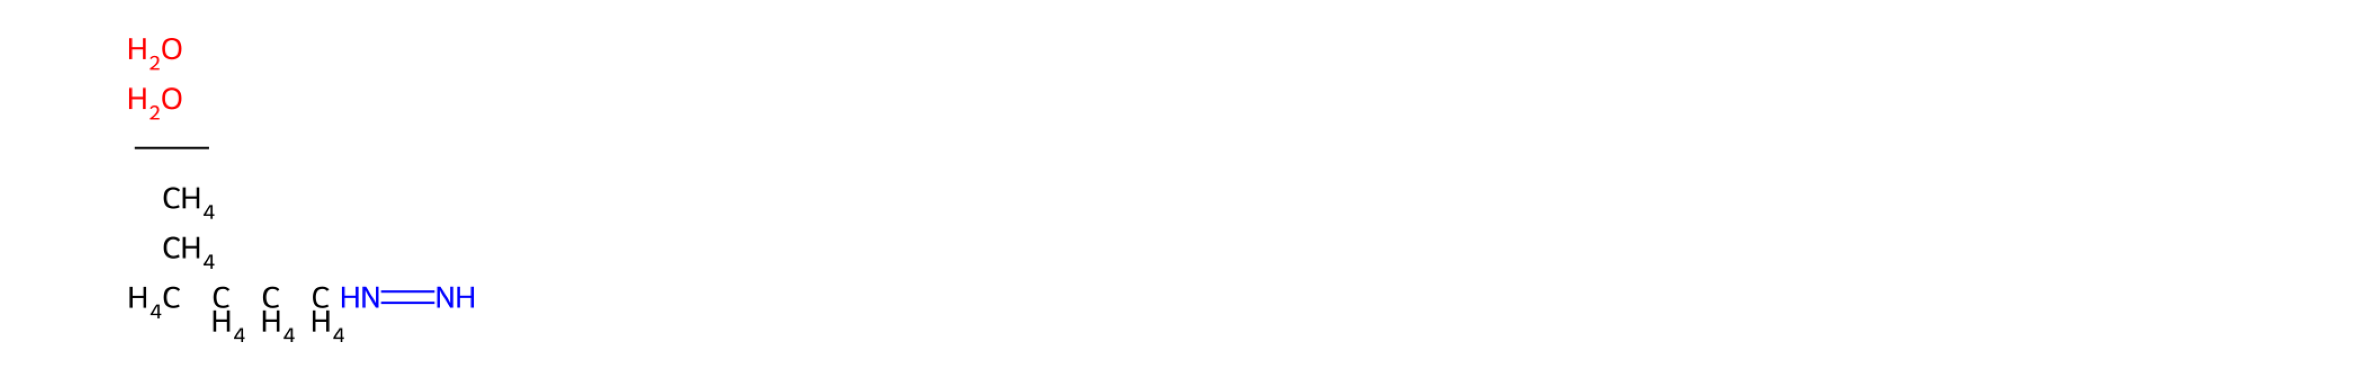

[graph 0] phase=1/4 beam_limit=2 fallback=0/3
[graph 0] phase=1/4 depth=1 remaining_edges=9 step_time=0m 34.3s eta=5m 8.3s
generated=192 feasible=98 retained=2 tried=192
best_score=0.376 best_target_score=0.000 best_selection_score=0.376 best_repulsion=0.000
target_lambda=0.500 repulsion_lambda=0.000 beam_limit=2


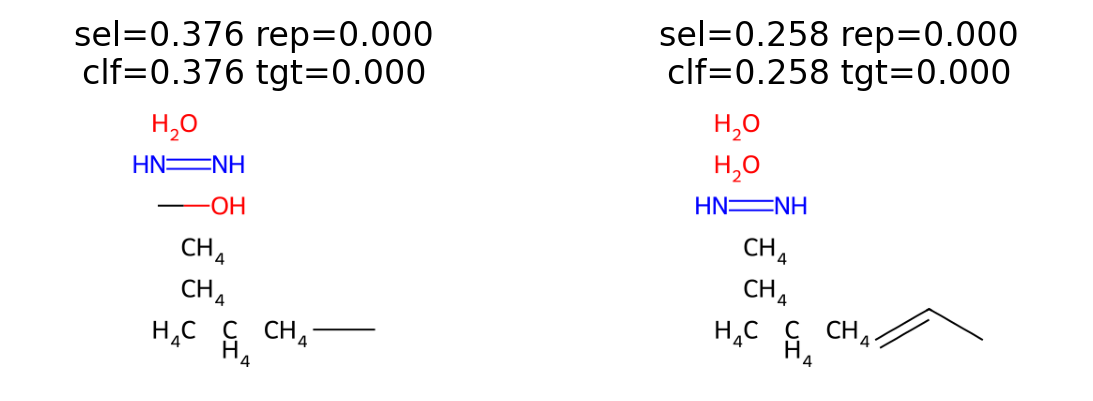

[graph 0] phase=1/4 depth=2 remaining_edges=8 step_time=0m 47.0s eta=6m 15.8s
generated=378 feasible=152 retained=2 tried=570
best_score=0.471 best_target_score=0.000 best_selection_score=0.471 best_repulsion=0.000
target_lambda=0.500 repulsion_lambda=0.000 beam_limit=2


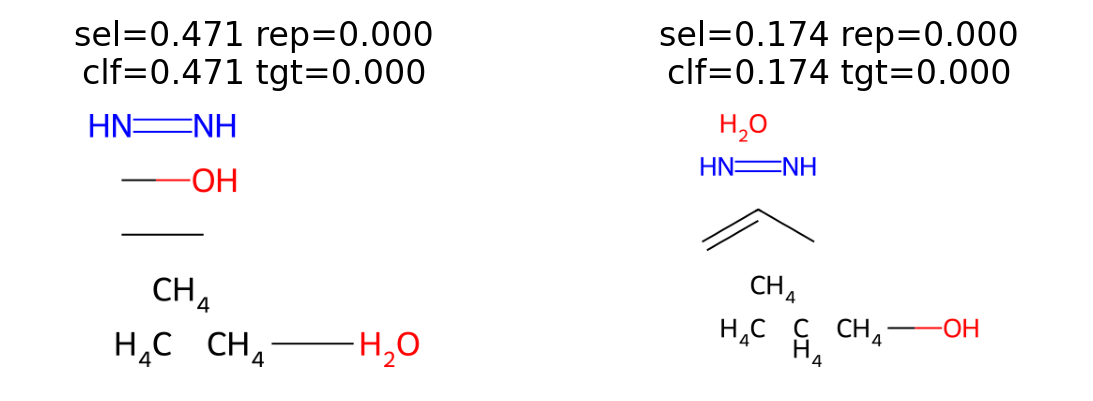

[graph 0] phase=1/4 depth=3 remaining_edges=7 step_time=0m 36.1s eta=4m 12.7s
generated=372 feasible=129 retained=2 tried=942
best_score=0.371 best_target_score=0.000 best_selection_score=0.371 best_repulsion=0.000
target_lambda=0.500 repulsion_lambda=0.000 beam_limit=2


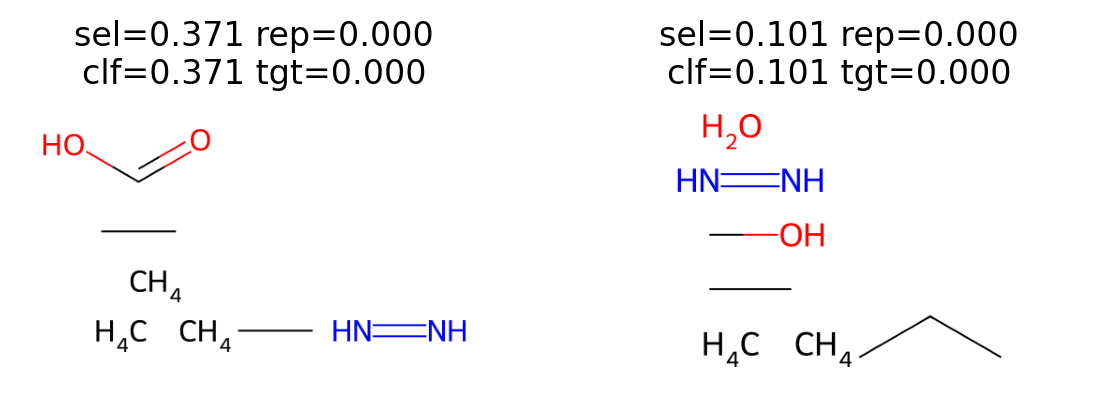

[graph 0] phase=1/4 depth=4 remaining_edges=6 step_time=0m 37.0s eta=3m 41.8s
generated=366 feasible=123 retained=2 tried=1308
best_score=0.501 best_target_score=0.000 best_selection_score=0.501 best_repulsion=0.000
target_lambda=0.500 repulsion_lambda=0.000 beam_limit=2


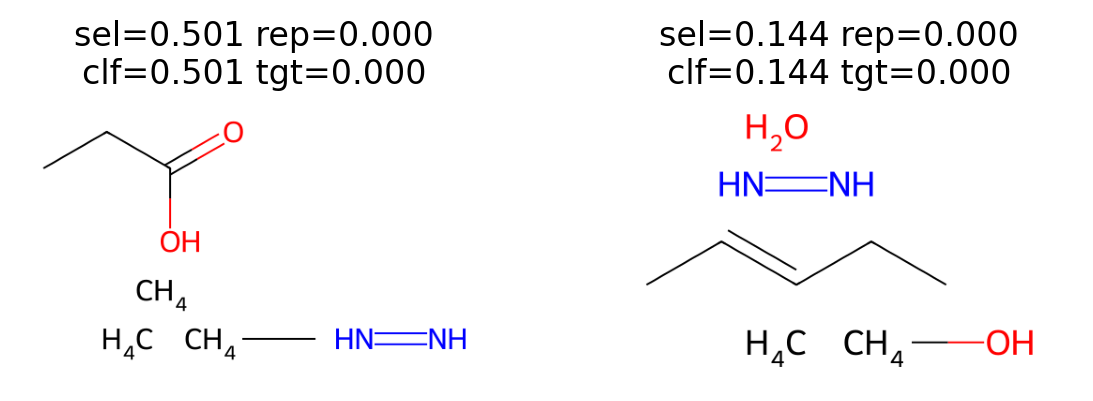

[graph 0] phase=1/4 depth=5 remaining_edges=5 step_time=0m 45.0s eta=3m 45.1s
generated=360 feasible=86 retained=2 tried=1668
best_score=0.905 best_target_score=0.000 best_selection_score=0.905 best_repulsion=0.000
target_lambda=0.500 repulsion_lambda=0.000 beam_limit=2


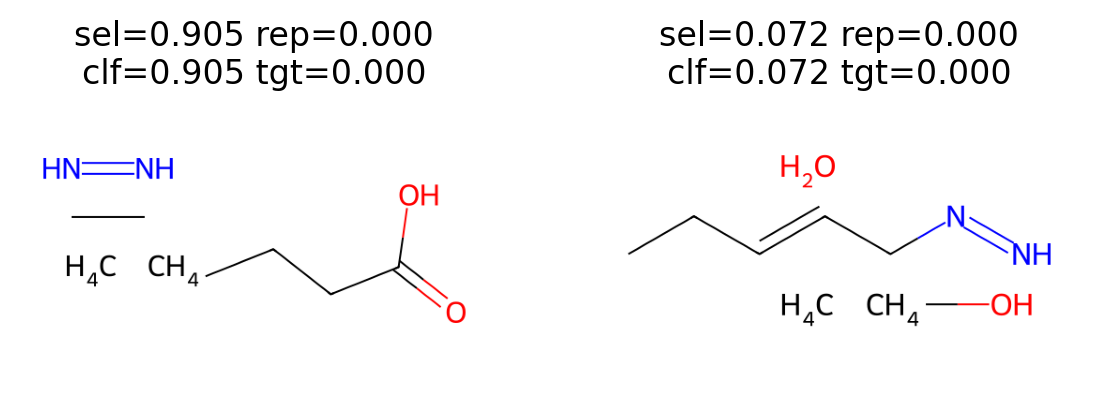

[graph 0] phase=1/4 depth=6 remaining_edges=4 step_time=0m 43.2s eta=2m 52.9s
generated=354 feasible=72 retained=2 tried=2022
best_score=0.917 best_target_score=0.000 best_selection_score=0.917 best_repulsion=0.000
target_lambda=0.500 repulsion_lambda=0.000 beam_limit=2


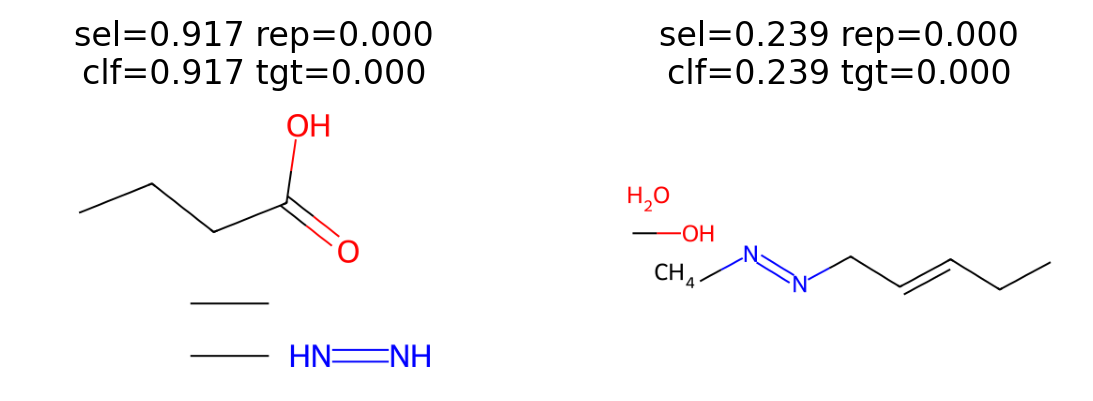

[graph 0] phase=1/4 depth=7 remaining_edges=3 step_time=0m 47.4s eta=2m 22.3s
generated=348 feasible=57 retained=2 tried=2370
best_score=0.819 best_target_score=0.000 best_selection_score=0.819 best_repulsion=0.000
target_lambda=0.500 repulsion_lambda=0.000 beam_limit=2


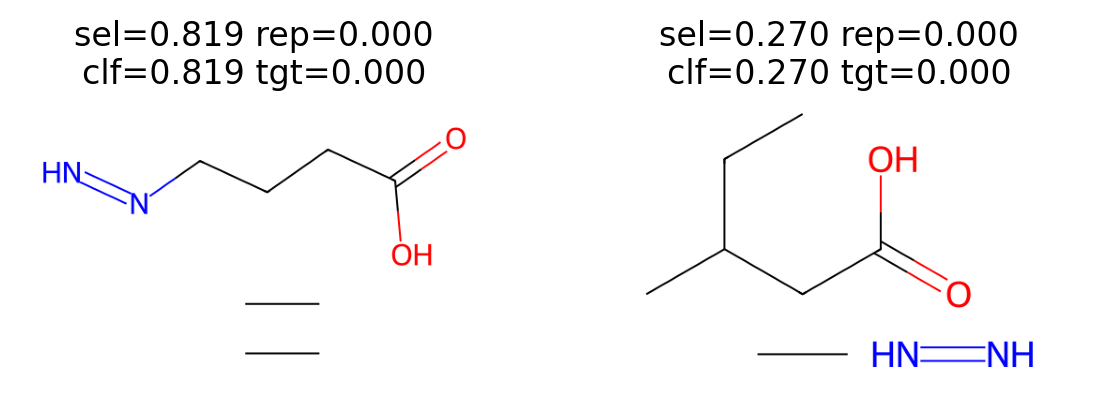

[graph 0] phase=1/4 depth=8 remaining_edges=2 step_time=0m 44.7s eta=1m 29.3s
generated=342 feasible=44 retained=2 tried=2712
best_score=0.903 best_target_score=0.000 best_selection_score=0.903 best_repulsion=0.000
target_lambda=0.500 repulsion_lambda=0.000 beam_limit=2


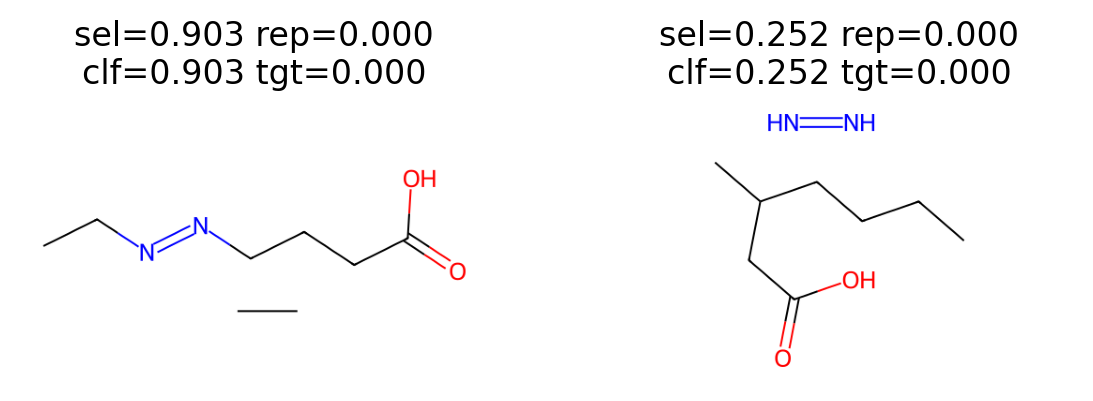

[graph 0] phase=1/4 depth=9 remaining_edges=1 step_time=0m 44.9s eta=0m 44.9s
generated=336 feasible=26 retained=2 tried=3048
best_score=0.833 best_target_score=0.000 best_selection_score=0.833 best_repulsion=0.000
target_lambda=0.500 repulsion_lambda=0.000 beam_limit=2


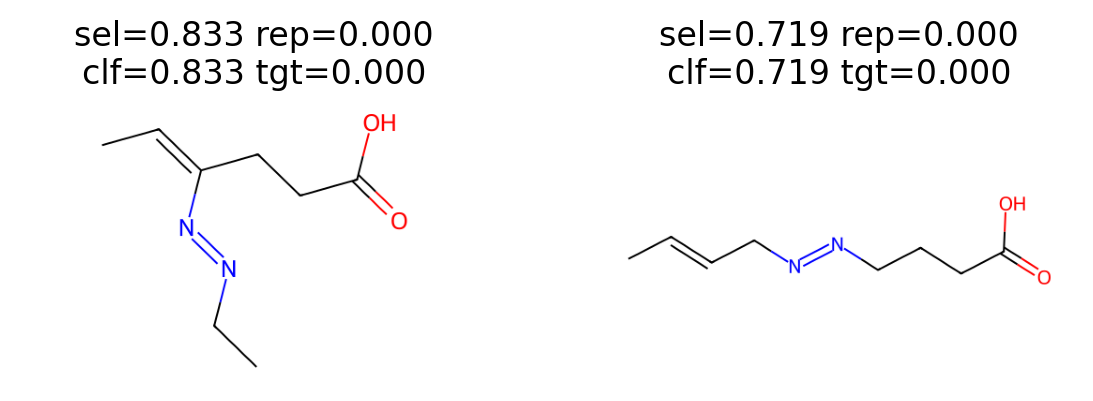

[graph 0] phase=1/4 depth=10 remaining_edges=0 step_time=0m 48.7s eta=0m 0.0s
generated=330 feasible=2 retained=2 tried=3378
best_score=0.667 best_target_score=0.000 best_selection_score=0.667 best_repulsion=0.000
target_lambda=0.500 repulsion_lambda=0.000 beam_limit=2


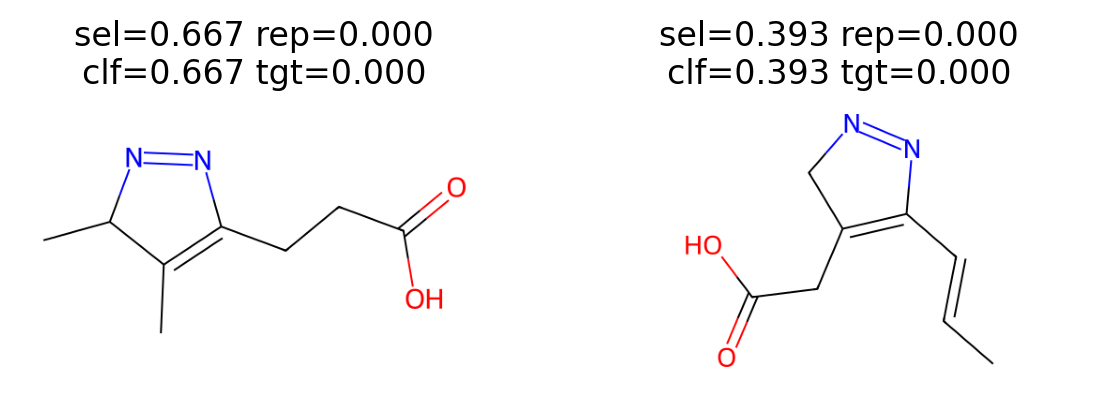

[graph 0] solved phase=1/4 depth=10 max_depth=10 edges=12 remaining_edges=0 tried=3378 elapsed=7m 11.4s eta=0m 0.0s
n_fit_graphs = 4
start_n_edges = 2
target_n_edges = 12
desired_target = None
generation_path_length = 11
Generation path:


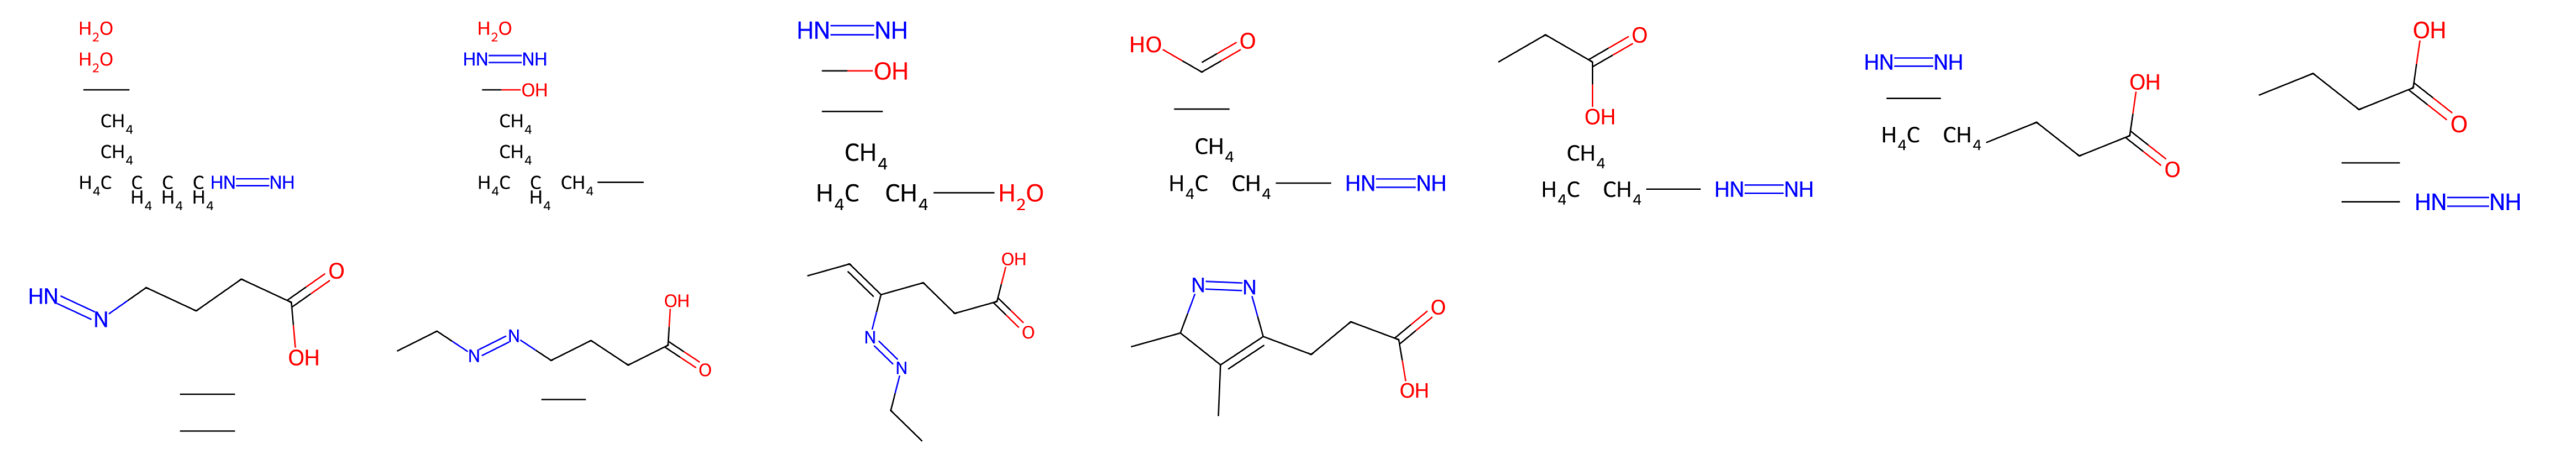

Resulting graph:


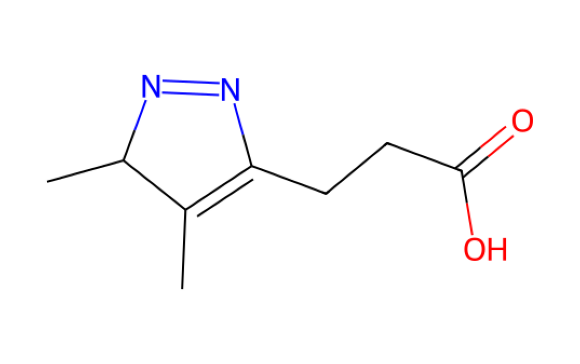

Original graph:


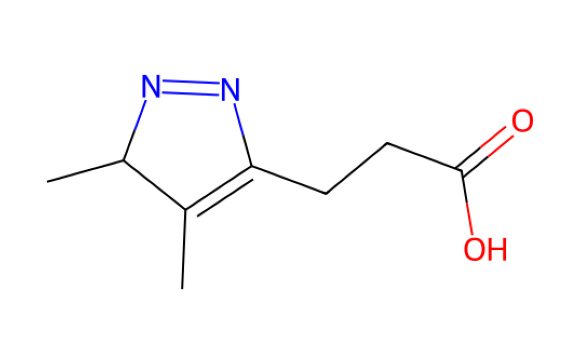

CPU times: user 35.8 s, sys: 8.86 s, total: 44.7 s
Wall time: 7min 12s


In [12]:
%%time
idx = random.randrange(len(fit_graphs))
graph = fit_graphs[idx]
print('Selecting random graph...')
_ = display_graphs([graph], n_graphs_per_line=1)

start_graph, target_n_edges = remove_edges(graph, size=.8)
desired_target = fit_targets[idx] if USE_TARGETS else None
target_lambda = 0.5
print('Removed edges to create start graph with target_n_edges =', target_n_edges)
_ = display_graphs([start_graph], n_graphs_per_line=1)

print('Generating path to target_n_edges =', target_n_edges, 'and desired_target =', desired_target)
generation_path = generator.generate(
    start_graph,
    n_edges=target_n_edges,
    target=desired_target,
    target_lambda=target_lambda,
    draw_graphs_fn=lambda graphs, **kwargs: display_graphs(graphs, **kwargs),
)

print('n_fit_graphs =', len(fit_graphs))
print('start_n_edges =', start_graph.number_of_edges())
print('target_n_edges =', target_n_edges)
print('desired_target =', desired_target)
print('generation_path_length =', len(generation_path))

print('Generation path:')
_ = display_graphs(generation_path, n_graphs_per_line=min(len(generation_path), 7))
print('Resulting graph:')
_ = display_graphs([generation_path[-1]], n_graphs_per_line=1)
print('Original graph:')
_ = display_graphs([graph], n_graphs_per_line=1)


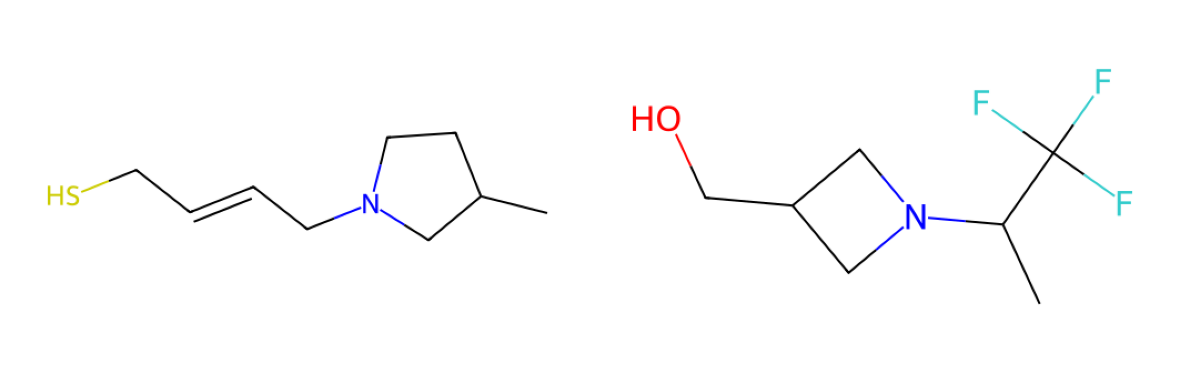

mixed_target_n_edges = 11
mixed_target = None


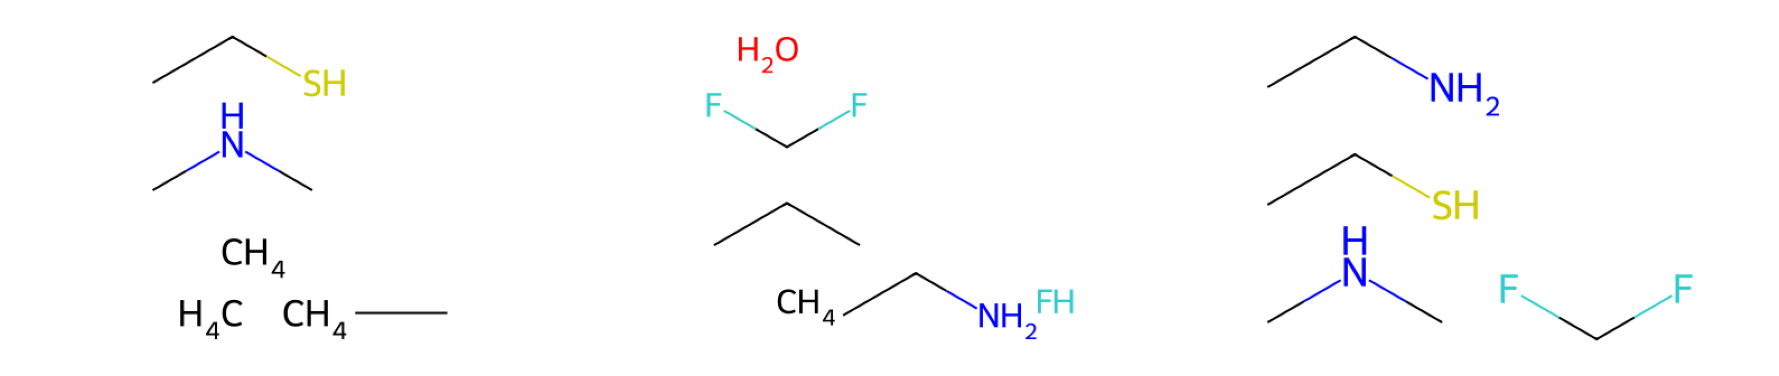

In [16]:
size = 0.5

from abstractgraph_generative.edge_generator import mix_connected_components

idx_a, idx_b = random.sample(range(len(fit_graphs)), k=2)
graph_a, graph_b = fit_graphs[idx_a], fit_graphs[idx_b]
target_a = fit_targets[idx_a] if USE_TARGETS else None
target_b = fit_targets[idx_b] if USE_TARGETS else None

_ = display_graphs([graph_a, graph_b], n_graphs_per_line=2)

start_graph_a, target_n_edges_a = remove_edges(graph_a, size=size)
start_graph_b, target_n_edges_b = remove_edges(graph_b, size=size)

mixed_graph = mix_connected_components(start_graph_a, start_graph_b, seed=0)
mixed_target_n_edges = int(np.mean([target_n_edges_a, target_n_edges_b]))
mixed_target = int(np.mean([target_a, target_b])) if USE_TARGETS else None

print(f"mixed_target_n_edges = {mixed_target_n_edges}")
print(f"mixed_target = {mixed_target}")

_ = display_graphs([start_graph_a, start_graph_b, mixed_graph], n_graphs_per_line=3)


[graph 0] start start_edges=8 target_edges=11 remaining_edges=3 target=None target_lambda=0.500


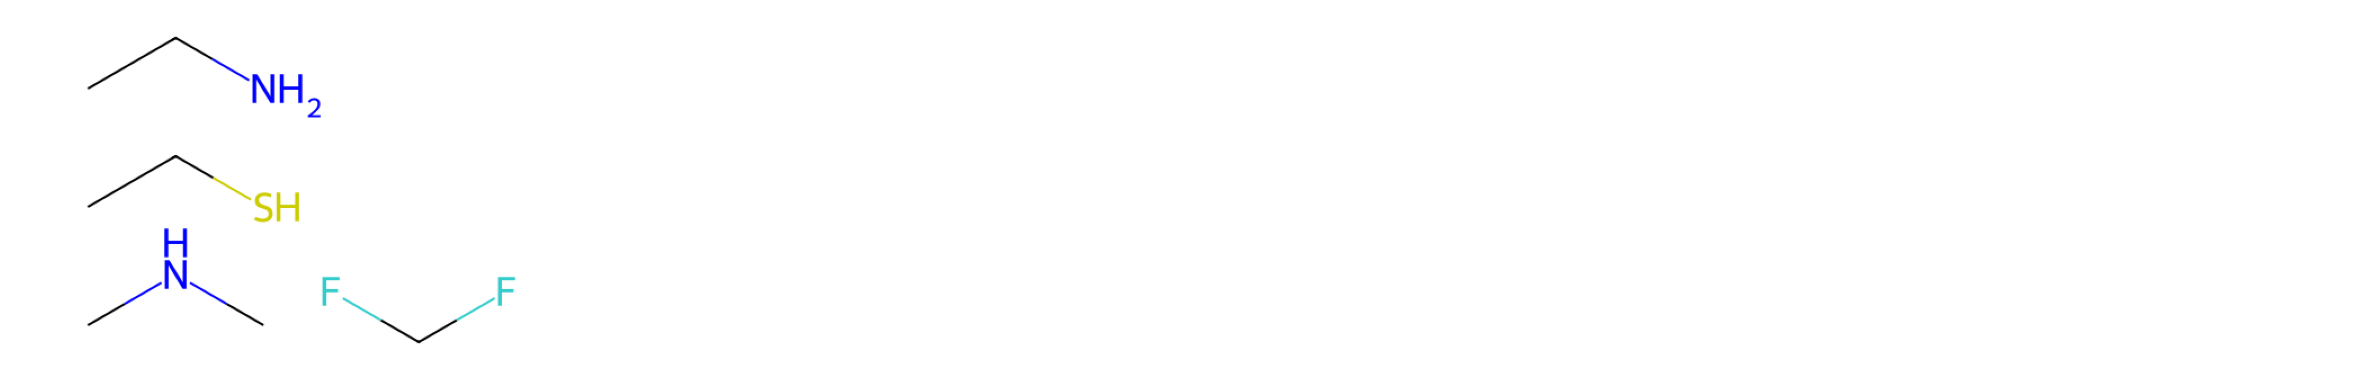

[graph 0] phase=1/4 beam_limit=2 fallback=0/3
[graph 0] phase=1/4 depth=1 remaining_edges=2 step_time=2m 57.5s eta=5m 55.0s
generated=174 feasible=23 retained=2 tried=174
best_score=0.803 best_target_score=0.000 best_selection_score=0.803 best_repulsion=0.000
target_lambda=0.500 repulsion_lambda=0.000 beam_limit=2


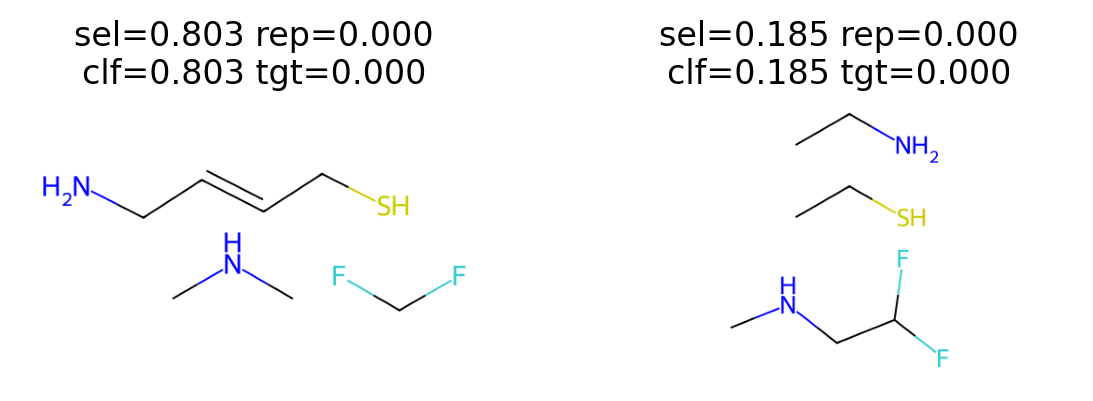

[graph 0] phase=1/4 depth=2 remaining_edges=1 step_time=1m 53.7s eta=1m 53.7s
generated=342 feasible=23 retained=2 tried=516
best_score=0.677 best_target_score=0.000 best_selection_score=0.677 best_repulsion=0.000
target_lambda=0.500 repulsion_lambda=0.000 beam_limit=2


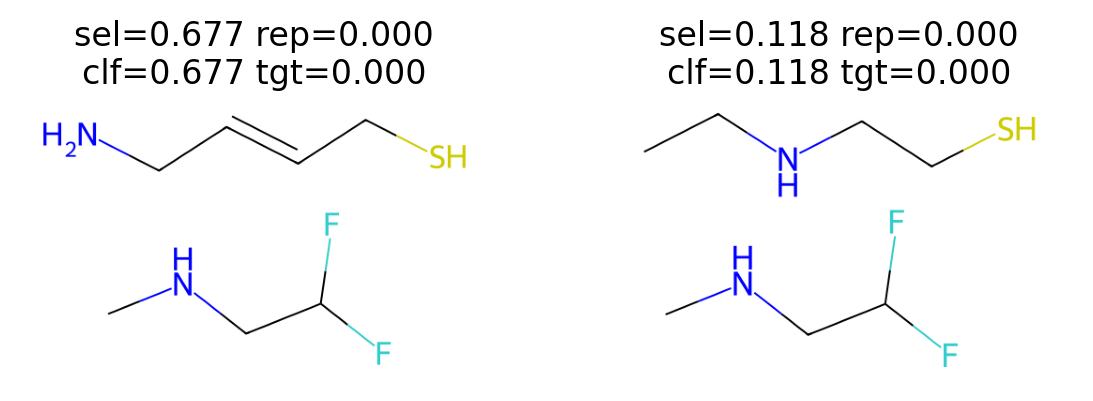

[graph 0] phase=1/4 depth=3 remaining_edges=0 step_time=1m 40.3s eta=0m 0.0s
generated=336 feasible=12 retained=2 tried=852
best_score=0.400 best_target_score=0.000 best_selection_score=0.400 best_repulsion=0.000
target_lambda=0.500 repulsion_lambda=0.000 beam_limit=2


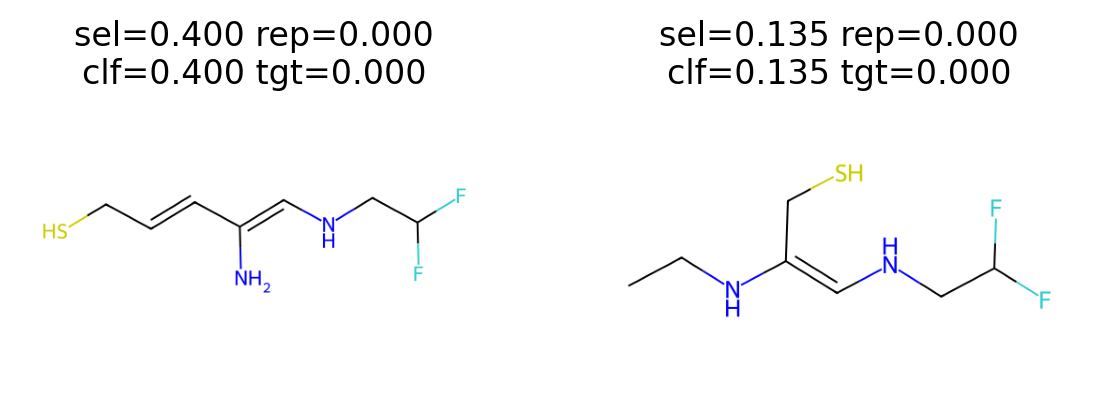

[graph 0] solved phase=1/4 depth=3 max_depth=3 edges=11 remaining_edges=0 tried=852 elapsed=6m 33.4s eta=0m 0.0s
n_fit_graphs = 4
start_n_edges = 2
target_n_edges = 12
mixed_target = None
generation_path_length = 4
Generation path:


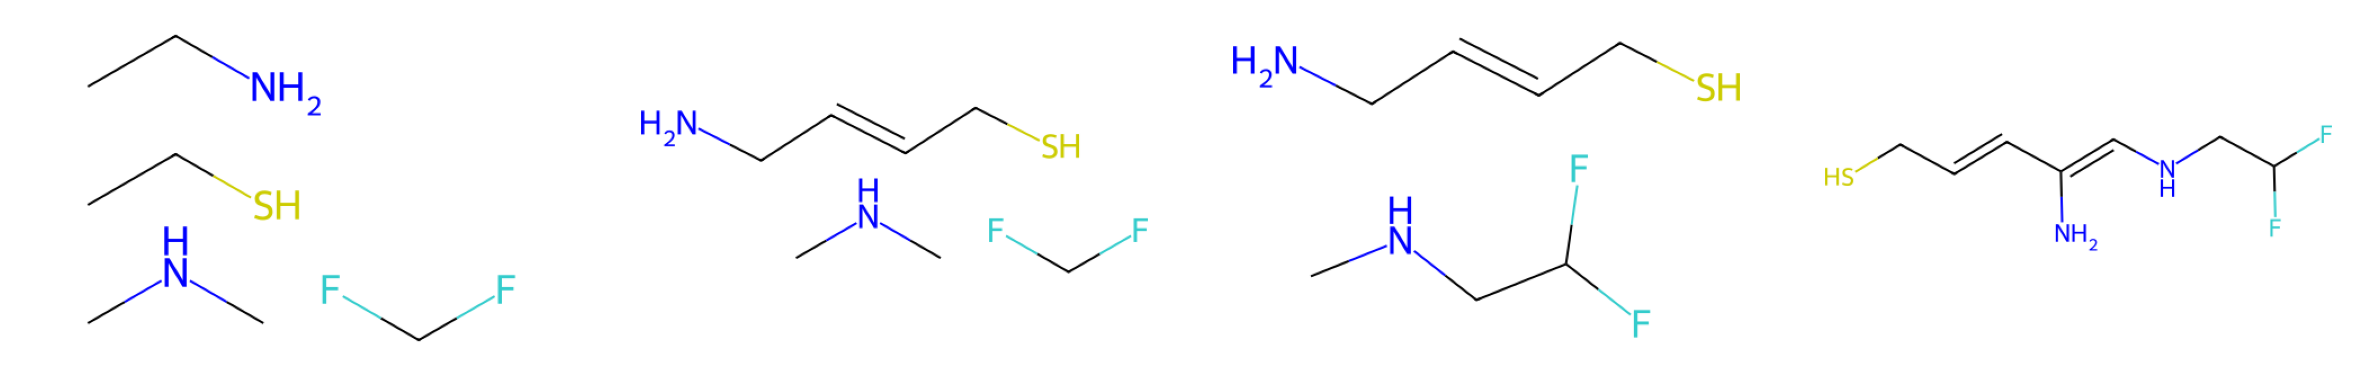

Resulting graph:


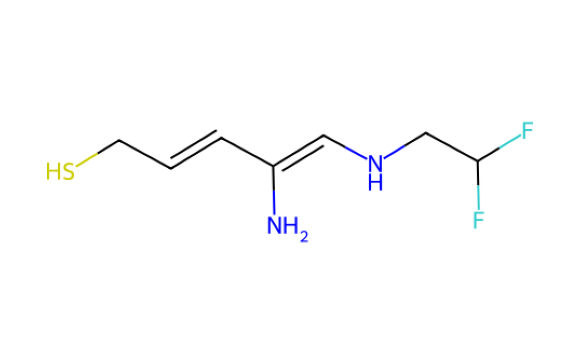

Original graphs:


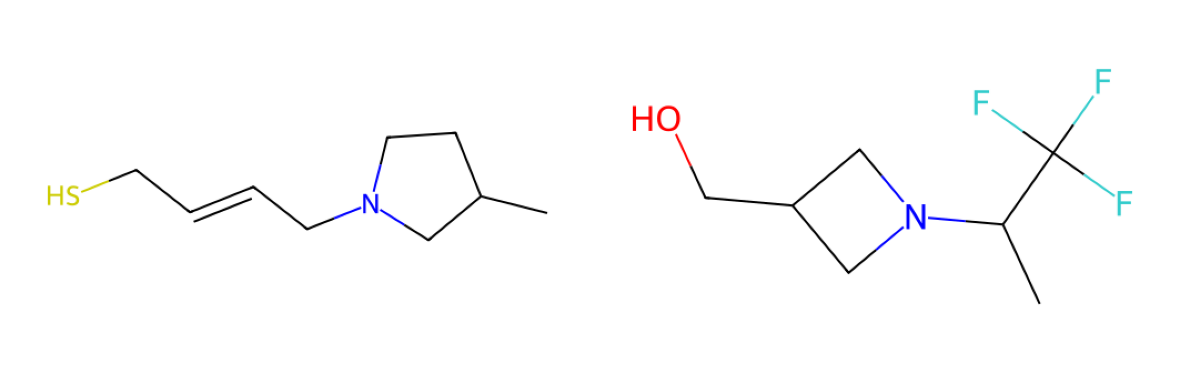

In [17]:
generation_path = generator.generate(
    mixed_graph,
    n_edges=mixed_target_n_edges,
    target=mixed_target,
    target_lambda=0.5,
    draw_graphs_fn=lambda graphs, **kwargs: display_graphs(graphs, **kwargs),
)
print('n_fit_graphs =', len(fit_graphs))
print('start_n_edges =', start_graph.number_of_edges())
print('target_n_edges =', target_n_edges)
print('mixed_target =', mixed_target)
print('generation_path_length =', len(generation_path))
print('Generation path:')
_ = display_graphs(generation_path, n_graphs_per_line=min(len(generation_path), 7))
print('Resulting graph:')
_ = display_graphs([generation_path[-1]], n_graphs_per_line=1)
print('Original graphs:')
_ = display_graphs([graph_a, graph_b], n_graphs_per_line=2)

---